In [1]:
#download the needed data and the needed libraries
!pip install yfinance -q #<- yfinance is the base for the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
#choose the tick for this case we use AAPL
ticker = "AAPL"
#then we choose the time for the data from something to something
df = yf.download(ticker, start="2023-01-01", end="2026-01-01")

/tmp/ipykernel_545/2267089792.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2023-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


In [3]:
#cleaning data since the data sometimes have additional row
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

In [4]:
#Calculate Fast and Slow Moving Averages (wont differ from one tick to the other)
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

In [14]:
# Signal = 1 when SMA_50 > SMA_200 (Bullish), else -1 or 0
# What happened is that the slow(MA200)went higher than the fast(MA50) it means high chance the whole picture goes down
# But if the fast(MA50) is higher than slow(MA200) it means high chance the whole data went up
df['Signal'] = 0
df.loc[df['SMA_50'] > df['SMA_200'], 'Signal'] = 1
df.loc[df['SMA_50'] <= df['SMA_200'], 'Signal'] = -1

In [15]:
# 5. Calculate Strategy Returns vs. Buy & Hold
df['Market_Returns'] = df['Close'].pct_change()
df['Strategy_Returns'] = df['Market_Returns'] * df['Signal'].shift(1)

# Calculate cumulative returns
df['Cumulative_Market'] = (1 + df['Market_Returns'].fillna(0)).cumprod()
df['Cumulative_Strategy'] = (1 + df['Strategy_Returns'].fillna(0)).cumprod()

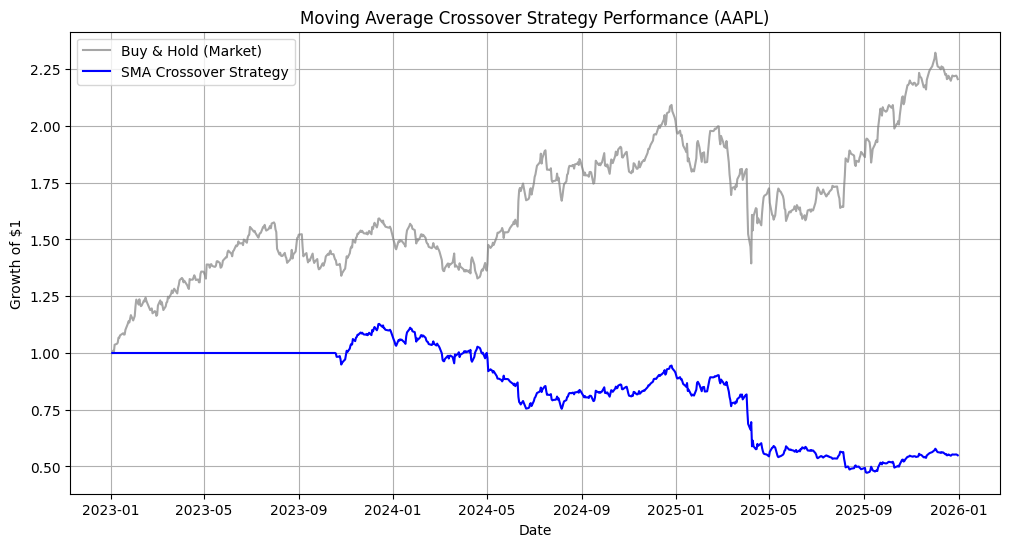

In [16]:
# 6. Plot the results using Matplotlib
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cumulative_Market'], label='Buy & Hold (Market)', color='gray', alpha=0.7)
plt.plot(df.index, df['Cumulative_Strategy'], label='SMA Crossover Strategy', color='blue')
plt.title(f'Moving Average Crossover Strategy Performance ({ticker})')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()